In [1]:
# !pip install kagglehub

In [4]:
import cv2
import json
import numpy as np
import kagglehub as kgh
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob as gg
from zipfile import ZipFile

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
token_mapping = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4',
    5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: '+', 11: '-', 12: '*', 13: '/', 14: '=',
    15: '(', 16: ')', 17: '\\lim', 18: '\\cot'
}

In [5]:
def preprocess_image_for_segmentation(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (800, 800))
    _, binary_image = cv2.threshold(image, 180, 255, cv2.THRESH_BINARY_INV)
    return image, binary_image

In [ ]:
def segment_image(binary_image, min_contour_size=10):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_contour_size]

    bounding_boxes = [b for b in bounding_boxes if b[2] > 0 and b[3] > 0]
    return bounding_boxes

In [ ]:
def extract_segments(image, bounding_boxes, target_size=(28,28)):
    segments = []
    for (x, y, w, h) in bounding_boxes:
        segment = image[y:y+h, x:x+w]

        if segment.size > 0:
            segment = cv2.resize(segment, target_size)
            segments.append(segment)
    return segments

In [8]:
def synchronous_pipeline(image_path, symbol_model, target_size = (28,28)):
    image, binary_image = preprocess_image_for_segmentation(image_path)
    bounding_boxes = segment_image(binary_image)
    bounding_boxes_sorted = sorted(bounding_boxes, key=lambda b: (b[1], b[0]))
    segments = extract_segments(image, bounding_boxes_sorted, target_size)

    predicted_tokens = []
    for seg in segments:
        if len(seg.shape) == 2:
            seg = cv2.cvtColor(seg, cv2.COLOR_GRAY2RGB)
        seg = seg.astype(np.float32) / 255.0
        seg_input = np.expand_dims(seg, axis=0)
        pred = symbol_model.predict(seg_input)
        pred_class = np.argmax(pred, axis=-1)[0]
        token = token_mapping.get(pred_class, '')
        predicted_tokens.append(token)
    predicted_sequence = "".join(predicted_tokens)
    return predicted_sequence

In [9]:
def plot_actual(batch):
    import matplotlib.pyplot as plt

    num = np.random.randint(0, 58)

    fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
    for idx, img in enumerate(batch[0][num:num + 5]):
        # ax[idx].imshow(img)
        ax[idx].imshow(img.astype(int))
        ax[idx].title.set_text(batch[1][num])
        ax[idx].axis("off")
        num += 1

In [ ]:
def plot_predictions(batch, label_symbol):
    import matplotlib.pyplot as plt

    num = np.random.randint(0, 58)

    fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
    for idx, img in enumerate(batch[0][num:num + 5]):
        ax[idx].imshow(img.astype(int))

        actual_class = label_symbol[batch[1][num]]

        img_array = np.expand_dims(img, axis = 0)
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        predicted_class = label_symbol[predicted_class_index]

        title = f"Actual: {actual_class}\n Predicted: {predicted_class}"
        ax[idx].set_title(title)
        ax[idx].axis("off")
        num += 1

    plt.show()

In [26]:
import os
from tensorflow.keras.models import load_model

# model_path = "./../models/symbol_model.keras"
model_path = "models/symbol_model.keras"

try:
    assert os.path.exists(model_path)
except AssertionError as ae:
    print(f"Path {model_path} not found! {ae}")

model = load_model(model_path)

In [28]:
# image_dataset = kgh.dataset_download("aidapearson/ocr-data")
image_dataset = "archive"

try:
    assert os.path.exists(image_dataset)
except AssertionError as ae:
    print(f"Path {image_dataset} not found! {ae}")

In [5]:
# images = gg(f"{image_dataset}/batch_*")
images = gg(f"{image_dataset}/batch_*/background_images/*")
json_files = gg(f"{image_dataset}/batch_*/JSON/*")
# /backgroung_images/*

NameError: name 'image_dataset' is not defined

In [30]:
image_dataset

'archive'

In [34]:
images[:5], json_files[:5]

(['archive/batch_1/background_images/fb74173c-8e79-4e2f-b4d9-d3e2bde3acee.jpg',
  'archive/batch_1/background_images/902e6f05-bc3d-48f7-92f3-195df63a83b1.jpg',
  'archive/batch_1/background_images/b748d0e6-2cc8-4e79-b11c-eeacd06eb11c.jpg',
  'archive/batch_1/background_images/871009f8-d10a-48b9-bf05-e8e566024bd4.jpg',
  'archive/batch_1/background_images/9e03af7d-9ce1-4f4a-aaaa-e2fd852fdd7a.jpg'],
 ['archive/batch_1/JSON/kaggle_data_1.json',
  'archive/batch_6/JSON/kaggle_data_6.json',
  'archive/batch_8/JSON/kaggle_data_8.json',
  'archive/batch_9/JSON/kaggle_data_9.json',
  'archive/batch_7/JSON/kaggle_data_7.json'])

In [40]:
type(model)

keras.src.models.sequential.Sequential

In [41]:
# symbols_zip_path = "/content/drive/MyDrive/Code/pre_training.zip"

In [42]:
# with ZipFile(symbols_zip_path, "r") as file:
#     # file.extractall(path = "/content/drive/MyDrive/Datasets/callbacks")
#     file.extractall(path = "/content/")
#     print("Done")
#     file.close()

In [44]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "symbol_images", batch_size = 64, image_size = (64, 64)
)

Found 701773 files belonging to 53 classes.


In [45]:
batch = dataset.as_numpy_iterator().next()

In [50]:
symbols_dict = dict(zip((range(0, len(dataset.class_names))), dataset.class_names))

with open("symbols_dict.json", "w") as file:
    json.dump(symbols_dict, file)

[symbols_dict[n] for n in range(10)]

['+', '-', '0', '1', '2', '3', '4', '5', '6', '7']

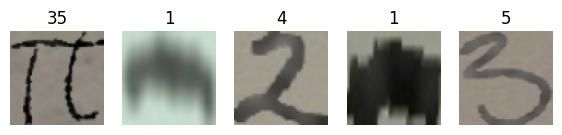

In [51]:
plot_actual(batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


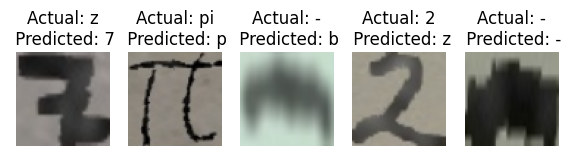

In [58]:
plot_predictions(batch, symbols_dict)

In [59]:
# preprocess_image_for_segmentation(image_path)
# segment_image(binary_image, min_contour_size = 10)
# extract_segments(image, bounding_boxes, target_size=(28,28)):
# synchronous_pipeline(images[0], model, target_size = (28,28))

In [ ]:
def segmentation_preprocessing(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (800, 300))
    _, binary_image = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY_INV)
    return image, binary_image

img, bin_img = segmentation_preprocessing(images[4])

plt.imshow(img)
plt.show()
plt.imshow(bin_img)
plt.show()

NameError: name 'images' is not defined

In [ ]:
def segment_image(binary_image, min_contour_area=10):

    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bounding_boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_contour_area]

    bounding_boxes = [b for b in bounding_boxes if b[2] > 0 and b[3] > 0]
    return bounding_boxes

img, bin_img = segmentation_preprocessing(images[4])
bb = segment_image(bin_img)
bb

[(54, 292, 8, 4),
 (79, 257, 11, 7),
 (260, 228, 68, 51),
 (188, 201, 66, 80),
 (314, 170, 5, 4),
 (36, 165, 10, 64),
 (339, 163, 23, 92),
 (69, 150, 85, 96),
 (45, 113, 9, 15),
 (3, 102, 17, 152),
 (588, 87, 109, 101),
 (695, 73, 49, 82),
 (759, 45, 38, 159),
 (421, 2, 262, 259)]

Exception ignored in: <function _xla_gc_callback at 0x789e0437f7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


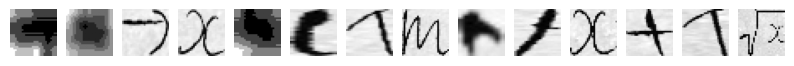

In [ ]:
def segment_image(binary_image, min_contour_area=10):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_contour_area]
    bounding_boxes = [b for b in bounding_boxes if b[2] > 0 and b[3] > 0]
    return bounding_boxes

def extract_segments(image, bounding_boxes, target_size=(28,28)):
    segments = []
    for (x, y, w, h) in bounding_boxes:
        segment = image[y:y+h, x:x+w]
        if segment.size > 0:
            segment = cv2.resize(segment, target_size)
            segments.append(segment)
    return segments

image, binary_image = preprocess_image_for_segmentation(images[4])
bounding_boxes = segment_image(binary_image, min_contour_area=10)
segments = extract_segments(image, bounding_boxes, target_size=(28,28))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, seg in enumerate(segments):
    plt.subplot(1, len(segments), i+1)
    plt.imshow(seg, cmap="gray")
    plt.axis("off")
plt.show()